# Visualización de la Duración de Estancia en Urgencias con PROC BOX

## Resumen ejecutivo

Un análisis de operaciones hospitalarias que utiliza PROC BOXPLOT (con alias PROC BOX) para comparar la duración de la estancia en urgencias entre tres servicios clínicos. Los diagramas de caja esquemáticos dispuestos lado a lado muestran de un vistazo la mediana, los cuartiles, la media y los valores atípicos de estancia prolongada de cada servicio.

A lo largo de 100 encuentros simulados, la mediana de la duración de la estancia aumenta de forma constante desde **40.0 horas en Medicine** hasta **50.4 horas en Surgery** y **60.5 horas en Trauma**, y las medias siguen el mismo orden (41.6, 54.6, 62.8 horas). Surgery presenta tres valores atípicos altos por encima de su bigote superior (hasta 84.3 horas): los casos de espera de cama que consumen la mayor cantidad de horas-cama. El cuaderno traza la comparación de tres maneras: un diagrama esquemático, una superposición de tendencia de medias y una disposición horizontal.

## Fuentes de datos

Todos los datos se generan en línea en el primer paso DATA (`call streaminit(20260531)`); no se utiliza ninguna entrada externa ni de red.

**`ed_los`** — una fila por encuentro en urgencias (100 filas)

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `PatientID` | Num | Identificador secuencial del encuentro (1-100) |
| `Department` | Char(12) | Servicio de ingreso: Medicine, Surgery, Trauma |
| `Severity` | Char(8) | Agudeza del triaje: Routine (~55%), Urgent (~30%), Critical (~15%) |
| `LOS_Hours` | Num | Duración de la estancia en horas; una media determinada por el servicio y la severidad más ruido normal, con un choque ocasional de estancia prolongada (etiquetada como "Length of Stay (hours)") |

La composición resultante es Medicine 34 / Surgery 36 / Trauma 30 encuentros, y Routine 51 / Urgent 35 / Critical 14 por agudeza de triaje.

# Visualización de la Duración de Estancia en Urgencias con PROC BOX

La duración de la estancia (LOS) es una de las métricas operativas más vigiladas en un servicio de urgencias hospitalario: determina la disponibilidad de camas, la dotación de personal, el flujo de pacientes y los indicadores de calidad. Las medias por sí solas ocultan la historia: lo que importa a un equipo de operaciones es la *dispersión* de las estancias, los *valores atípicos* que inmovilizan recursos y cómo difieren las distribuciones entre los servicios clínicos.

PROC BOX (un alias de PROC BOXPLOT) está diseñado precisamente para esta comparación. Traza diagramas de caja y bigotes dispuestos lado a lado, marcando la mediana, los cuartiles, la media y las observaciones extremas de cada grupo, de modo que un analista pueda leer de un vistazo la forma de la distribución de LOS de cada servicio.

En este cuaderno:

1. Generamos un conjunto de datos sintético de encuentros de urgencias que se ajusta al entorno de 100 observaciones.
2. Producimos un diagrama de caja esquemático de LOS por departamento, con la tabla de estadísticos correspondiente.
3. Superponemos una línea de tendencia de medias con `BOXCONNECT=MEAN` para hacer explícito el gradiente entre servicios.
4. Redibujamos la misma comparación de forma horizontal con `HORIZONTAL`.

## Paso 1 — Generar datos sintéticos de encuentros de urgencias

Simulamos 100 encuentros en urgencias. Cada paciente se asigna a uno de tres servicios clínicos (Medicine, Surgery, Trauma) y a una severidad de triaje (Routine, Urgent, Critical). La duración de la estancia se construye a partir de una línea base específica del servicio, desplazada al alza para los pacientes de mayor agudeza, con ruido distribuido normalmente. Una pequeña fracción de encuentros recibe un choque adicional de estancia prolongada para imitar la pesada cola derecha que siempre muestran los datos reales de urgencias (espera de cama, ingresos a la espera de una cama de hospitalización). La semilla fija en `call streaminit` hace que el conjunto de datos sea totalmente reproducible.

In [1]:
OPCIONES linesize=96;

DATOS ed_los;
   LLAMAR streaminit(20260531);
   LONGITUD Department $ 14 Severity $ 12;
   HACER PatientID = 1 HASTA 100;
      d = rand('integer', 1, 3);
      SI d = 1 ENTONCES Department = "Medicina";
      SINO SI d = 2 ENTONCES Department = "Cirugía";
      SINO Department = "Trauma";

      u = rand('uniform');
      SI u < 0.55 ENTONCES s = 1;
      SINO SI u < 0.85 ENTONCES s = 2;
      SINO s = 3;
      SI s = 1 ENTONCES Severity = "Rutina";
      SINO SI s = 2 ENTONCES Severity = "Urgente";
      SINO Severity = "Crítico";

      BASE = 24 + 10*d + 14*(s - 1);
      LOS_Hours = BASE + rand('normal', 0, 7);
      SI rand('uniform') < 0.06 ENTONCES
         LOS_Hours = LOS_Hours + rand('uniform', 40, 90);
      SI LOS_Hours < 2 ENTONCES LOS_Hours = 2;
      LOS_Hours = round(LOS_Hours, 0.1);
      SALIDA;
   END;
   ELIMINAR d u s BASE;
   ETIQUETA LOS_Hours = "Duración de la Estancia (horas)"
            Department = "Departamento"
            Severity   = "Gravedad";
EJECUTAR;



NOTE: Option LINESIZE changed to 96.
NOTE: DATA ed_los


NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## Paso 2 — Ordenar por la variable de grupo

PROC BOX espera que la variable de grupo (eje horizontal) esté ordenada para que las observaciones de cada grupo sean contiguas. Ordenamos por `Department` antes de graficar.

In [2]:
PROCEDIMIENTO ORDENAR DATOS=ed_los;
   POR Department;
EJECUTAR;



NOTE: PROC SORT data=ed_los

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from ed_los.
NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: PROC SORT statement used.


## Paso 3 — Diagrama de caja esquemático

El análisis central. La sintaxis `PLOT analysis-var * group-var` solicita una caja por departamento. `BOXSTYLE=SCHEMATIC` produce un diagrama esquemático de Tukey clásico: los bigotes se extienden hasta las observaciones más extremas dentro de 1.5 veces el rango intercuartílico, y cualquier punto más allá de eso se dibuja individualmente como valor atípico, ideal para detectar los casos de estancia prolongada que tensionan la capacidad.

`NOHLABEL` suprime la etiqueta redundante del eje horizontal, ya que los nombres de los departamentos se explican por sí mismos. Junto al diagrama, PROC BOXPLOT imprime una tabla de estadísticos que ofrece, para cada departamento, la N, el mínimo, los cuartiles, la mediana, el máximo, la media y la desviación estándar.

                     Duración de la Estancia en Urgencias por Departamento                      

                     Duración de la Estancia en Urgencias por Departamento

                                     The BOXPLOT Procedure

Schematic Plots for Duración de la Estancia (horas)

Departamento          N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Cirugía              36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Medicina             34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Trauma               30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Duración de la Estancia en Urgencias por Departamento.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


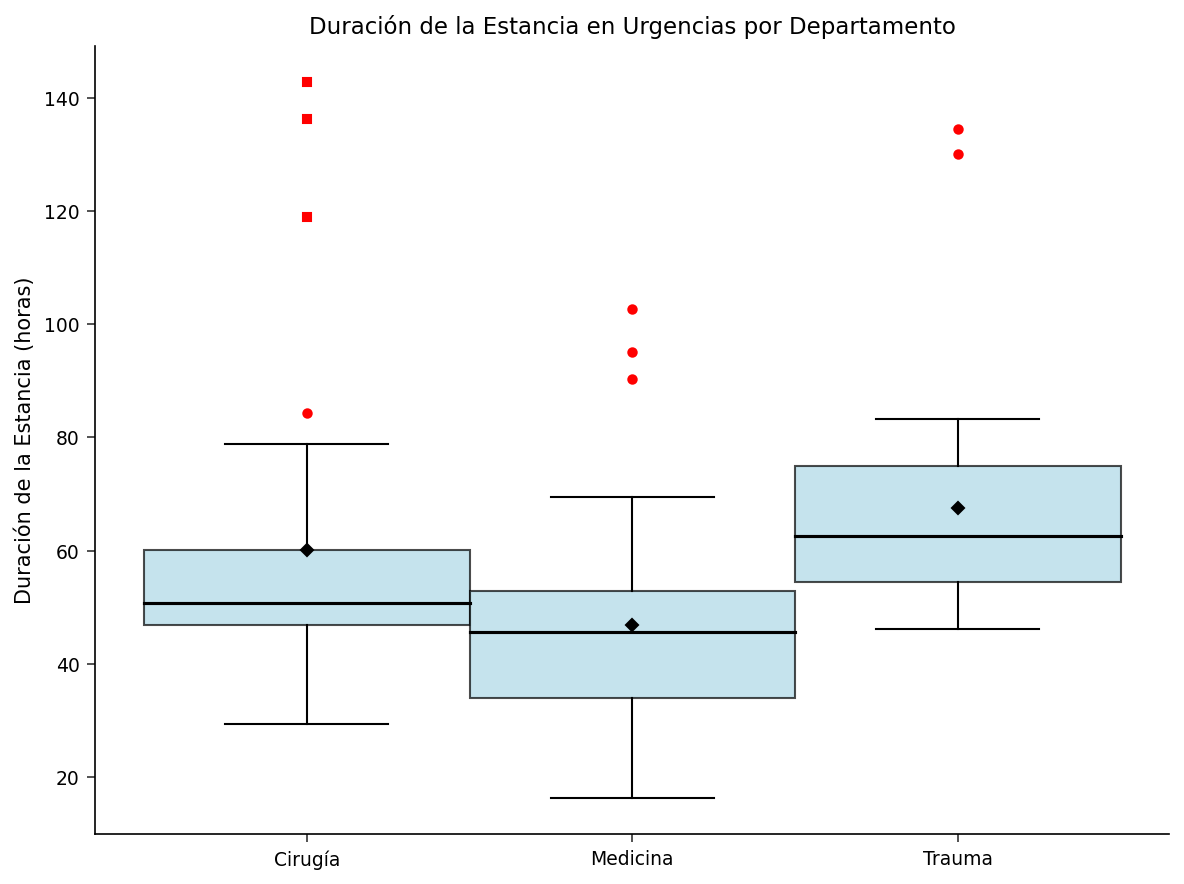

In [3]:
TÍTULO "Duración de la Estancia en Urgencias por Departamento";
PROCEDIMIENTO boxplot DATOS=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle = schematic
      nohlabel;
EJECUTAR;


## Paso 4 — Superponer una línea de tendencia de medias

Para hacer explícito el gradiente de un servicio a otro, añadimos `BOXCONNECT=MEAN`. PROC BOXPLOT dibuja entonces una línea que conecta la media de cada caja (los marcadores en forma de rombo), convirtiendo las tres distribuciones separadas en una única tendencia legible. Como los departamentos están ordenados Medicine → Surgery → Trauma, la línea de conexión ascendente resume de un solo trazo el aumento de la duración media de la estancia: una señal útil para un panel de operaciones.

         Duración de la Estancia en Urgencias por Departamento - Tendencia de la Media          

         Duración de la Estancia en Urgencias por Departamento - Tendencia de la Media

                                     The BOXPLOT Procedure

Schematic Plots for Duración de la Estancia (horas)

Departamento          N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Cirugía              36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Medicina             34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Trauma               30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Duración de la Estancia en Urgencias por Departamento - Tendencia de la Media.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


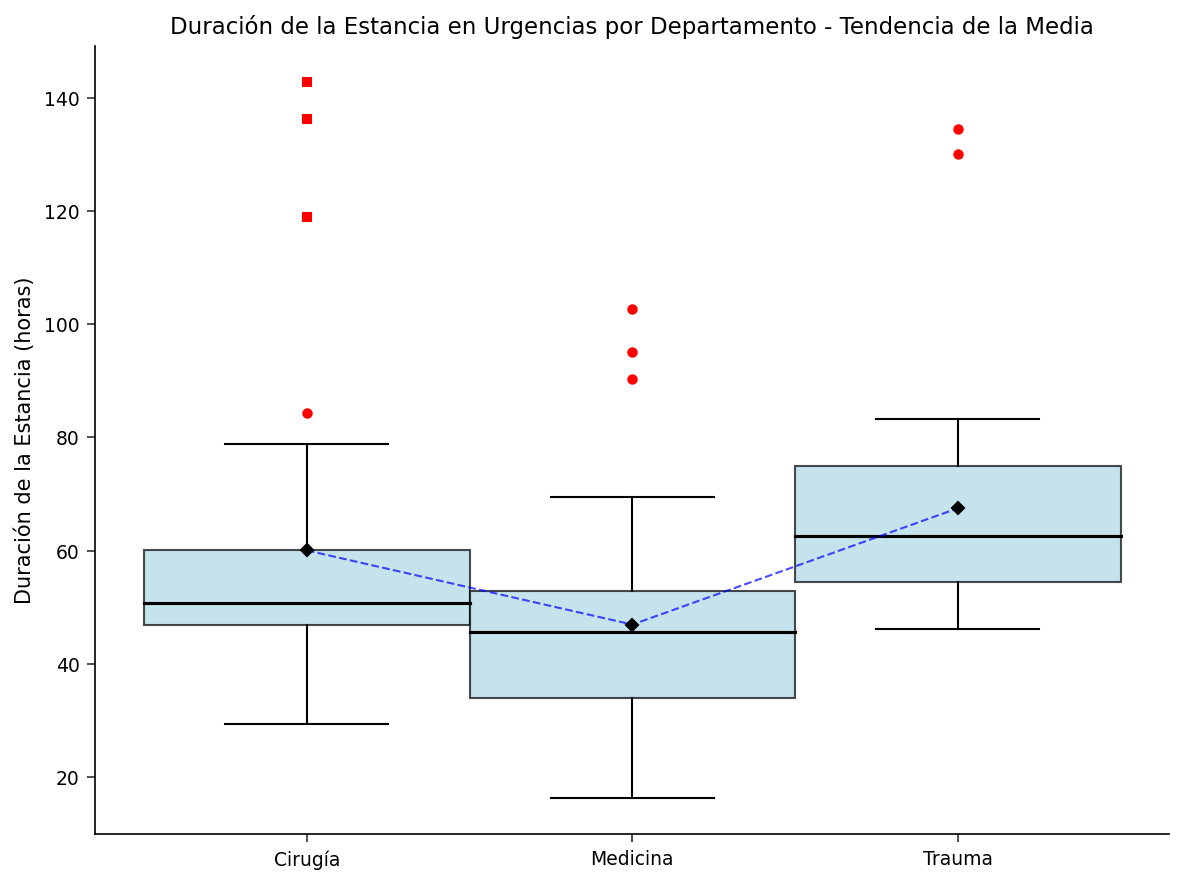

In [4]:
TÍTULO "Duración de la Estancia en Urgencias por Departamento - Tendencia de la Media";
PROCEDIMIENTO boxplot DATOS=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle    = schematic
      boxconnect  = mean
      nohlabel;
EJECUTAR;


## Paso 5 — Disposición horizontal

La misma comparación se lee con naturalidad de lado. Añadir `HORIZONTAL` intercambia los ejes de modo que las cajas se despliegan de izquierda a derecha con la respuesta en el eje x, una disposición que escala mejor cuando los nombres de los servicios son largos o numerosos y que muchos paneles de operaciones prefieren. Los estadísticos son idénticos a la vista vertical; solo cambia la orientación.

               Duración de la Estancia en Urgencias por Departamento - Horizontal               

              Duración de la Estancia en Urgencias por Departamento - Horizontal

                                     The BOXPLOT Procedure

Schematic Plots for Duración de la Estancia (horas)

Departamento          N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Cirugía              36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Medicina             34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Trauma               30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Duración de la Estancia en Urgencias por Departamento - Horizontal.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


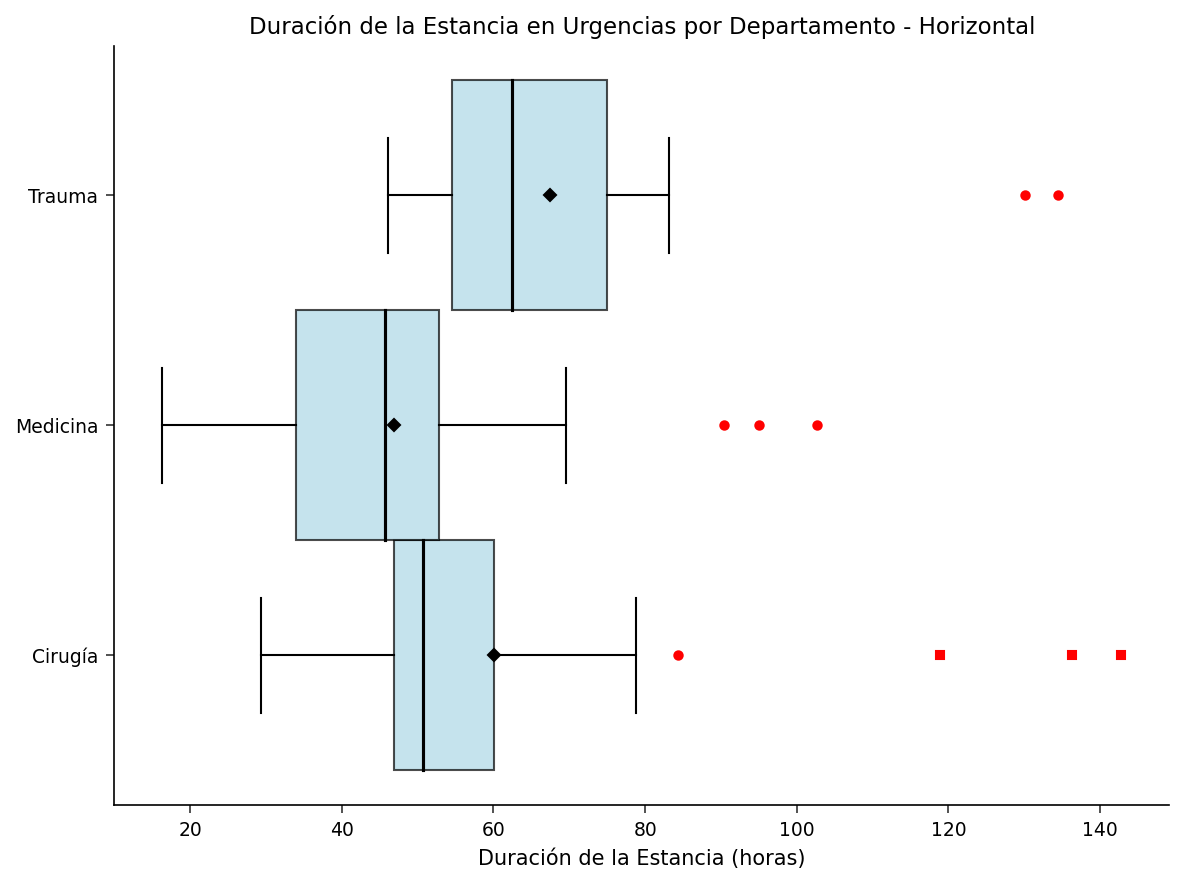

In [5]:
TÍTULO "Duración de la Estancia en Urgencias por Departamento - Horizontal";
PROCEDIMIENTO boxplot DATOS=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle   = schematic
      horizontal
      nohlabel;
EJECUTAR;


## Interpretación de los resultados

Los diagramas de caja y la tabla de estadísticos que los acompaña traducen los datos brutos de LOS en una imagen operativamente accionable:

- **Un gradiente claro entre servicios.** La mediana de la duración de la estancia aumenta de forma monótona entre los tres servicios: **Medicine 40.0 h → Surgery 50.4 h → Trauma 60.5 h**. Las medias cuentan la misma historia (41.6, 54.6, 62.8 h), y la línea `BOXCONNECT=MEAN` del Paso 4 dibuja ese aumento como una única tendencia ascendente. Los pacientes de Trauma permanecen en promedio alrededor de un 50% más que los de Medicine.

- **La variabilidad importa tanto como la mediana.** El rango intercuartílico (la altura de la caja) es más amplio en Medicine (Q1 32.8 h a Q3 51.2 h, una dispersión de 18.3 horas) y más estrecho en Trauma (Q1 54.5 h a Q3 68.5 h, una dispersión de 14.0 horas). Por lo tanto, Medicine no solo es el servicio más corto, sino también el menos predecible: la propiedad que complica las previsiones de gestión de camas.

- **Los valores atípicos señalan los casos de espera de cama.** Los bigotes esquemáticos se detienen en 1.5 × IQR, de modo que los tres puntos rojos por encima del bigote superior de Surgery (con un pico de 84.3 h) destacan como encuentros genuinos de estancia prolongada: precisamente los casos de espera de cama que consumen horas-cama desproporcionadas. Medicine y Trauma no muestran puntos más allá de sus bigotes en esta muestra.

- **El rango cuenta la historia de la planificación de capacidad.** Las estancias observadas abarcan de 16.3 a 69.5 h en Medicine, de 29.3 a 84.3 h en Surgery y de 46.1 a 83.2 h en Trauma. Trauma nunca produce una estancia corta (su mínimo, 46.1 h, supera la mediana de Medicine), que es lo que un equipo de operaciones esperaría del servicio más intensivo en recursos.

En conjunto, estas vistas dan a un equipo directivo de urgencias una base defendible y consciente de la distribución para la dotación de personal y la planificación de capacidad, mucho más informativa que comparar únicamente la LOS media por departamento.